In [128]:

import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
print(torch.__version__)

2.9.0+cu126


IMAGE LOADING

In [129]:
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch
import torchvision.transforms as transforms

In [130]:

ROOT = Path("Dataset/bottle")


train_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),

    transforms.RandomRotation(degrees=10),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),

    transforms.ToTensor()
])

In [131]:
class BottleTrainDataset(Dataset):

    def __init__(self, image_paths, transform=None, num_samples=10000):
        self.image_paths = image_paths
        self.transform = transform
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image_path = self.image_paths[idx % len(self.image_paths)]
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

In [132]:
image_paths = list(
    (ROOT / "train" / "good").glob("*.png")
)
print("Original images:", len(image_paths))

Original images: 209


In [133]:
train_dataset = BottleTrainDataset(
    image_paths=image_paths,
    transform=train_transform,
    num_samples=10000
)

In [134]:

print("Number of training images:", len(train_dataset))
print("Image shape:", train_dataset[0].shape)
print ("Image tensor:", train_dataset[0])

Number of training images: 10000
Image shape: torch.Size([3, 256, 256])
Image tensor: tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])


In [135]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [136]:
images = next(iter(train_loader))
print(images.shape)

torch.Size([16, 3, 256, 256])


In [137]:
len(train_loader)

625

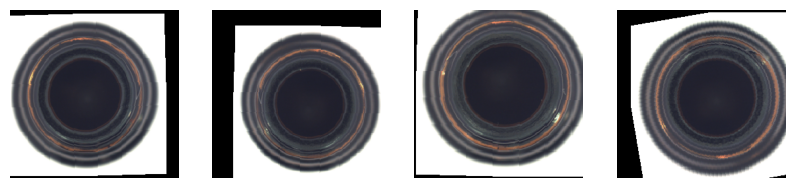

In [138]:
import matplotlib.pyplot as plt
images = next(iter(train_loader))
plt.figure(figsize=(10, 5))
for i in range(4):

    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.axis("off")

plt.show()

In [139]:
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

In [140]:
class BottleTestDataset(Dataset):
    def __init__(self, root, transform=None):
        self.image_paths = []
        self.labels = []

        test_path = root / "test"
        for defect_folder in test_path.iterdir():
            if not defect_folder.is_dir():
                continue
            if defect_folder.name == "good":
                label = 0
            else:
                label = 1

            for image_path in defect_folder.glob("*.png"):
                self.image_paths.append(image_path)
                self.labels.append(label)
                print(f"Image path: {image_path}, Label: {label}")
        self.transform = transform
        print(transform)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        image = Image.open(image_path).convert("RGB")
        label = self.labels[index]
        if self.transform:
            image = self.transform(image)

        return image, label

In [141]:
test_dataset = BottleTestDataset(
    ROOT,
    transform=test_transform
)

print("Number of test images:", len(test_dataset))

Image path: Dataset\bottle\test\broken_large\000.png, Label: 1
Image path: Dataset\bottle\test\broken_large\001.png, Label: 1
Image path: Dataset\bottle\test\broken_large\002.png, Label: 1
Image path: Dataset\bottle\test\broken_large\003.png, Label: 1
Image path: Dataset\bottle\test\broken_large\004.png, Label: 1
Image path: Dataset\bottle\test\broken_large\005.png, Label: 1
Image path: Dataset\bottle\test\broken_large\006.png, Label: 1
Image path: Dataset\bottle\test\broken_large\007.png, Label: 1
Image path: Dataset\bottle\test\broken_large\008.png, Label: 1
Image path: Dataset\bottle\test\broken_large\009.png, Label: 1
Image path: Dataset\bottle\test\broken_large\010.png, Label: 1
Image path: Dataset\bottle\test\broken_large\011.png, Label: 1
Image path: Dataset\bottle\test\broken_large\012.png, Label: 1
Image path: Dataset\bottle\test\broken_large\013.png, Label: 1
Image path: Dataset\bottle\test\broken_large\014.png, Label: 1
Image path: Dataset\bottle\test\broken_large\015.png, L

In [142]:
BATCH_SIZE = 16

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [143]:
from collections import Counter
print(Counter(test_dataset.labels))

Counter({1: 63, 0: 20})


In [144]:
print(train_dataset[0])
print(len(train_dataset))
print(train_dataset[0].shape)

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.],
         [0., 0., 0.,  ..., 1., 1., 1.]]])
10000
torch.Size([3, 256, 256])


Model Building Script 

The important idea for anomaly detection is that the autoencoder is trained using the normal good bottle images. It learns to reconstruct the normal appearance. Later, when an anomalous bottle is given to it, the reconstruction error can be used as an anomaly signal. This is the basic reconstruction-based approach relevant to the MVTec setup

In [145]:
from torch import nn, optim

Conv AutoEncoder

In [146]:
import torch
import torch.nn as nn


class ConvAE(nn.Module):

    def __init__(self):
        super().__init__()

        # ENCODER
        # Input: 3 x 256 x 256

        self.encoder = nn.Sequential(

            # 3 x 256 x 256
            # Additional layer for 256x256 input
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 128 x 128
            nn.Conv2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.Conv2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.Conv2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.Conv2d(
                32, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 32 x 32
            nn.Conv2d(
                64, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 32 x 32
            nn.Conv2d(
                64, 128,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 16 x 16
            nn.Conv2d(
                128, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16
            nn.Conv2d(
                64, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),
            #32 x 16 x 16
            nn.Conv2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 8 x 8
            # Latent representation
            nn.Conv2d(
                32, 128,
                kernel_size=8,
                stride=1,
                padding=0
            )

            # Output: 128 x 1 x 1
        )
        # DECODER

        self.decoder = nn.Sequential(

            # 128 x 1 x 1
            nn.ConvTranspose2d(
                128, 32,
                kernel_size=8,
                stride=1,
                padding=0
            ),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 x 8 x 8
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),
            # 32 x 16 x 16
            nn.ConvTranspose2d(
                32, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 8 x 8
            nn.ConvTranspose2d(
                64, 128,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 128 x 8 x 8
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16
            nn.ConvTranspose2d(
                64, 64,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 64 x 16 x 16
            nn.ConvTranspose2d(
                64, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 x 32
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 x 32
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 32 x 32
            nn.ConvTranspose2d(
                32, 32,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.LeakyReLU(0.2, inplace=True),

            # 32 x 64 x 64
            nn.ConvTranspose2d(
                32, 3,
                kernel_size=4,
                stride=2,
                padding=1
            )

            # Output: 3 x 256 x 256
        )


    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [147]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
x = torch.rand(3, 3).to(device)

Using device: cuda


In [148]:
torch.manual_seed(42)

In [149]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ConvAE().to(device)

print(model)

ConvAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): LeakyReLU(negative_slope=0.2, inplace=True)
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): LeakyReLU(negative_slope=0.2, inplace=True)
    (12): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (13): LeakyReLU(negative_slope=0.2, inplace=True)
    (14): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), paddin

In [150]:
x = torch.randn(4, 3, 256, 256).to(device)

with torch.no_grad():
    encoded = model.encoder(x)
    decoded = model.decoder(encoded)

print("Input:", x.shape)
print("Encoded:", encoded.shape)
print("Decoded:", decoded.shape)

Input: torch.Size([4, 3, 256, 256])
Encoded: torch.Size([4, 128, 1, 1])
Decoded: torch.Size([4, 3, 256, 256])


In [151]:
from torch.nn import MSELoss
loss_fn = MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0002
)

In [152]:
print(next(model.parameters()).device)

cuda:0


In [153]:
images = next(iter(train_loader))

print(images.device)

images = images.to(device)

print(images.device)

cpu
cuda:0


In [155]:
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

print("Model device:", next(model.parameters()).device)

images = next(iter(train_loader))
images = images.to(device)

print("Input device:", images.device)

CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
GPU count: 1
Model device: cuda:0
Input device: cuda:0


In [156]:
EPOCHS=20
train_losses = []
for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0

    for images in train_loader:
        images = images.to(device)
        reconstructed = model(images)
        loss = loss_fn(reconstructed, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(
    f"Epoch [{epoch + 1}/{EPOCHS}], "
    f"Loss: {epoch_loss:.6f}"
)

Epoch [1/20], Loss: 0.012272
Epoch [2/20], Loss: 0.009503
Epoch [3/20], Loss: 0.008263
Epoch [4/20], Loss: 0.007450
Epoch [5/20], Loss: 0.006917
Epoch [6/20], Loss: 0.006555
Epoch [7/20], Loss: 0.006151
Epoch [8/20], Loss: 0.006221
Epoch [9/20], Loss: 0.005835
Epoch [10/20], Loss: 0.005581
Epoch [11/20], Loss: 0.005459
Epoch [12/20], Loss: 0.005417
Epoch [13/20], Loss: 0.005133
Epoch [14/20], Loss: 0.004991
Epoch [15/20], Loss: 0.005003
Epoch [16/20], Loss: 0.004742
Epoch [17/20], Loss: 0.004761
Epoch [18/20], Loss: 0.004621
Epoch [19/20], Loss: 0.004532
Epoch [20/20], Loss: 0.004624


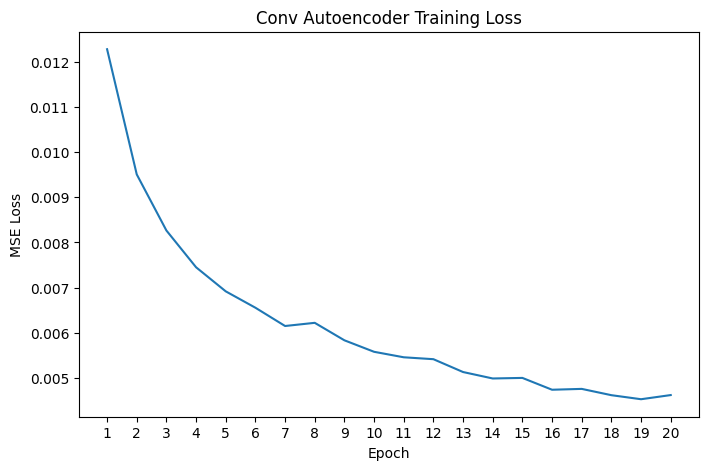

In [157]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, EPOCHS + 1), train_losses)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Conv Autoencoder Training Loss")
plt.xticks(range(1, EPOCHS + 1))

plt.show()

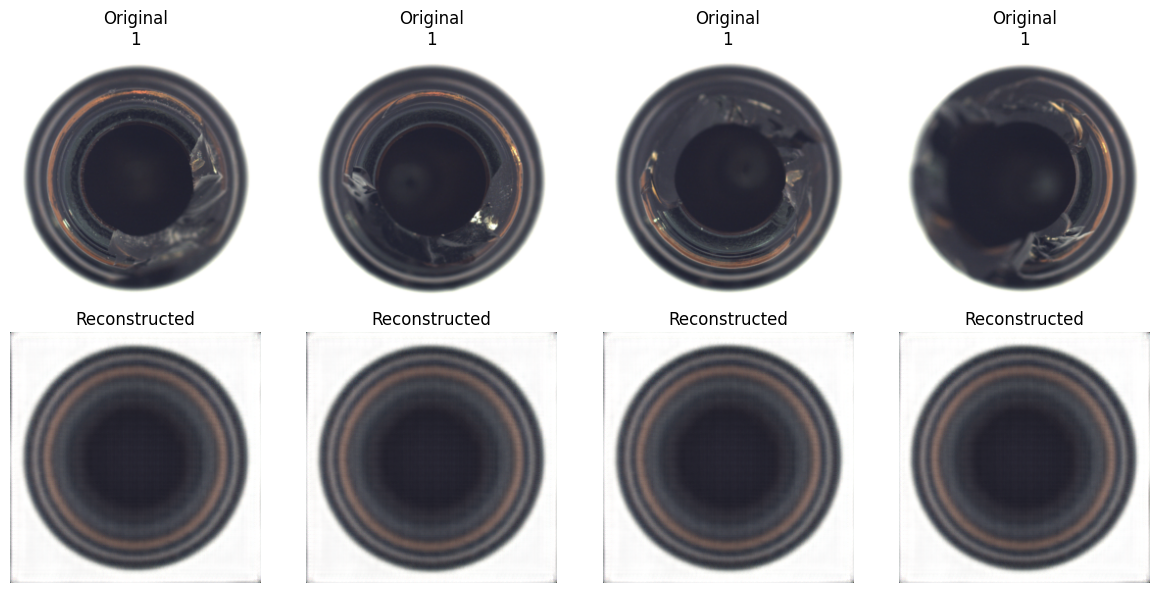

In [158]:
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructed = model(images)

fig = plt.figure(figsize=(12, 6))

for i in range(4):

    # Original
    plt.subplot(2, 4, i + 1)
    plt.imshow(
        images[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title(f"Original\n{labels[i].item()}")
    plt.axis("off")

    # Reconstruction
    plt.subplot(2, 4, i + 5)
    plt.imshow(
        reconstructed[i].cpu().permute(1, 2, 0).clamp(0, 1)
    )
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [159]:
model.eval()

all_errors = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        original = images
        reconstructed = model(images)
        errors = torch.mean(
            (images - reconstructed) ** 2,
            dim=(1, 2, 3)
        )

        all_errors.extend(errors.cpu().numpy())
        all_labels.extend(labels.numpy())

In [160]:
print(all_errors)
print(all_errors[0])
print(all_errors[0].shape)
print(len(all_errors))

[np.float32(0.004512013), np.float32(0.004426969), np.float32(0.00390952), np.float32(0.005826831), np.float32(0.008417454), np.float32(0.004406282), np.float32(0.0056166863), np.float32(0.0045627756), np.float32(0.004884732), np.float32(0.0034981098), np.float32(0.0038916122), np.float32(0.0038176798), np.float32(0.0065044235), np.float32(0.005377098), np.float32(0.0069698608), np.float32(0.0034044979), np.float32(0.00540937), np.float32(0.005951041), np.float32(0.0051489645), np.float32(0.0045830673), np.float32(0.0034341372), np.float32(0.0046884743), np.float32(0.005060151), np.float32(0.0071154325), np.float32(0.013591769), np.float32(0.0030783522), np.float32(0.004967733), np.float32(0.003334767), np.float32(0.0029450934), np.float32(0.003232422), np.float32(0.0048292796), np.float32(0.0037775147), np.float32(0.007617943), np.float32(0.0042734914), np.float32(0.0038611894), np.float32(0.0029442152), np.float32(0.0030455028), np.float32(0.0073671616), np.float32(0.01326089), np.fl

In [161]:
threshold = 0.0020
predicted_labels = [
    1 if error > threshold else 0
    for error in all_errors
]

In [162]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(
    all_labels,
    predicted_labels
)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels , predicted_labels))

print("\nClassification Report:")
print(classification_report(all_labels, predicted_labels))

Accuracy: 0.7590361445783133

Confusion Matrix:
[[ 0 20]
 [ 0 63]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        20
           1       0.76      1.00      0.86        63

    accuracy                           0.76        83
   macro avg       0.38      0.50      0.43        83
weighted avg       0.58      0.76      0.66        83



c:\Users\jaysu\anaconda3\envs\dl_env_up\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jaysu\anaconda3\envs\dl_env_up\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jaysu\anaconda3\envs\dl_env_up\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

## Finding the Optimal Threshold
Instead of manually guessing, we use data-driven methods:
1. **Training set statistics** — mean + k*std of normal reconstruction errors
2. **ROC / Youden's J** — maximizes balanced accuracy
3. **Precision-Recall / F1** — maximizes F1 score

Maximum image-level reconstruction MSE

In [163]:
import numpy as np
train_errors = []

model.eval()
error = 0
with torch.no_grad():
    for images in train_loader:
        images = images.to(device)
        original = images
        reconstructed = model(images)
        batch_error =  torch.mean((original - reconstructed) ** 2,dim=(1,2,3))
        error = max(error,batch_error.max().item())
print("Max Error Threshold value",error)

Max Error Threshold value 0.009268431924283504


Maximum PIXEL-level reconstruction MSE

In [164]:
model.eval()

max_pixel_error = 0.0

with torch.no_grad():

    for images in train_loader:

        images = images.to(device)
        reconstructed = model(images)
        original = images
        pixel_error = (original - reconstructed) ** 2
        batch_max_error = pixel_error.max().item()
        max_pixel_error = max(max_pixel_error, batch_max_error)

print("Maximum Pixel-Level Error Threshold:", max_pixel_error)

Maximum Pixel-Level Error Threshold: 1.3532849550247192


K-Sigma Threshold

In [165]:
import numpy as np
train_errors = []

model.eval()
with torch.no_grad():
    for images in train_loader:
        images = images.to(device)
        original = images
        reconstructed = model(images)
        error = torch.mean((original - reconstructed) ** 2, dim=(1,2,3))
        train_errors.extend(error.cpu().numpy())

mean_err = np.mean(train_errors)
std_err = np.std(train_errors)

threshold_2std = mean_err + 2 * std_err
threshold_3std = mean_err + 3 * std_err

print(f"Training error stats:")
print(f"  Mean: {mean_err:.6f}")
print(f"  Std:  {std_err:.6f}")
print(f"  Threshold (mean + 2*std): {threshold_2std:.6f}")
print(f"  Threshold (mean + 3*std): {threshold_3std:.6f}")

Training error stats:
  Mean: 0.004248
  Std:  0.000907
  Threshold (mean + 2*std): 0.006063
  Threshold (mean + 3*std): 0.006970


p-Quantile Threshold

In [166]:
model.eval()

all_pixel_errors = []

with torch.no_grad():
    for images in train_loader:
        images = images.to(device)
        original = images
        reconstructed = model(images)
        pixel_error = (original - reconstructed) ** 2
        all_pixel_errors.append(
            pixel_error.cpu().numpy().reshape(-1)
        )

all_pixel_errors = np.concatenate(all_pixel_errors)
p = 0.99
quantile_threshold = np.quantile(
    all_pixel_errors,
    p
)

print("p-Quantile Threshold:", quantile_threshold)

p-Quantile Threshold: 0.067548476


THESE USES TEST DATA LABELS 

In [167]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

all_errors_np = np.array(all_errors)
all_labels_np = np.array(all_labels)

# Method 2: ROC Curve + Youden's J statistic
fpr, tpr, roc_thresholds = roc_curve(all_labels_np, all_errors_np)
roc_auc = auc(fpr, tpr)

j_scores = tpr - fpr  
best_roc_idx = np.argmax(j_scores)
threshold_youden = roc_thresholds[best_roc_idx]

print(f"Method 2 - ROC / Youden's J:")
print(f"  AUC-ROC: {roc_auc:.4f}")
print(f"  Optimal threshold: {threshold_youden:.6f}")
print(f"  At this threshold -> TPR: {tpr[best_roc_idx]:.3f}, FPR: {fpr[best_roc_idx]:.3f}")

precision, recall, pr_thresholds = precision_recall_curve(all_labels_np, all_errors_np)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_pr_idx = np.argmax(f1_scores)
threshold_f1 = pr_thresholds[best_pr_idx]

print(f"\nMethod 3 - Precision-Recall / Best F1:")
print(f"  Optimal threshold: {threshold_f1:.6f}")
print(f"  At this threshold -> Precision: {precision[best_pr_idx]:.3f}, Recall: {recall[best_pr_idx]:.3f}, F1: {f1_scores[best_pr_idx]:.3f}")

Method 2 - ROC / Youden's J:
  AUC-ROC: 0.8103
  Optimal threshold: 0.004224
  At this threshold -> TPR: 0.683, FPR: 0.100

Method 3 - Precision-Recall / Best F1:
  Optimal threshold: 0.003232
  At this threshold -> Precision: 0.808, Recall: 0.937, F1: 0.868


In [168]:

thresholds_to_test = {
    "Manual (your current)": 0.0020,
    "Mean + 2*Std (training)": threshold_2std,
    "Mean + 3*Std (training)": threshold_3std,
    "Youden's J (ROC)": threshold_youden,
    "Best F1 (PR curve)": threshold_f1,
}

for name, t in thresholds_to_test.items():
    preds = [1 if e > t else 0 for e in all_errors]
    acc = accuracy_score(all_labels_np, preds)
    cm = confusion_matrix(all_labels_np, preds)
    print(cm)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n--- {name} (threshold = {t:.6f}) ---")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    print(f"  Recall (defect detection): {tp/(tp+fn):.3f}")
    print(f"  Precision: {tp/(tp+fp):.3f}" if (tp+fp) > 0 else "  Precision: N/A")

[[ 0 20]
 [ 0 63]]

--- Manual (your current) (threshold = 0.002000) ---
  Accuracy: 0.7590
  TP=63, FP=20, FN=0, TN=0
  Recall (defect detection): 1.000
  Precision: 0.759
[[20  0]
 [49 14]]

--- Mean + 2*Std (training) (threshold = 0.006063) ---
  Accuracy: 0.4096
  TP=14, FP=0, FN=49, TN=20
  Recall (defect detection): 0.222
  Precision: 1.000
[[20  0]
 [52 11]]

--- Mean + 3*Std (training) (threshold = 0.006970) ---
  Accuracy: 0.3735
  TP=11, FP=0, FN=52, TN=20
  Recall (defect detection): 0.175
  Precision: 1.000
[[18  2]
 [21 42]]

--- Youden's J (ROC) (threshold = 0.004224) ---
  Accuracy: 0.7229
  TP=42, FP=2, FN=21, TN=18
  Recall (defect detection): 0.667
  Precision: 0.955
[[ 6 14]
 [ 5 58]]

--- Best F1 (PR curve) (threshold = 0.003232) ---
  Accuracy: 0.7711
  TP=58, FP=14, FN=5, TN=6
  Recall (defect detection): 0.921
  Precision: 0.806


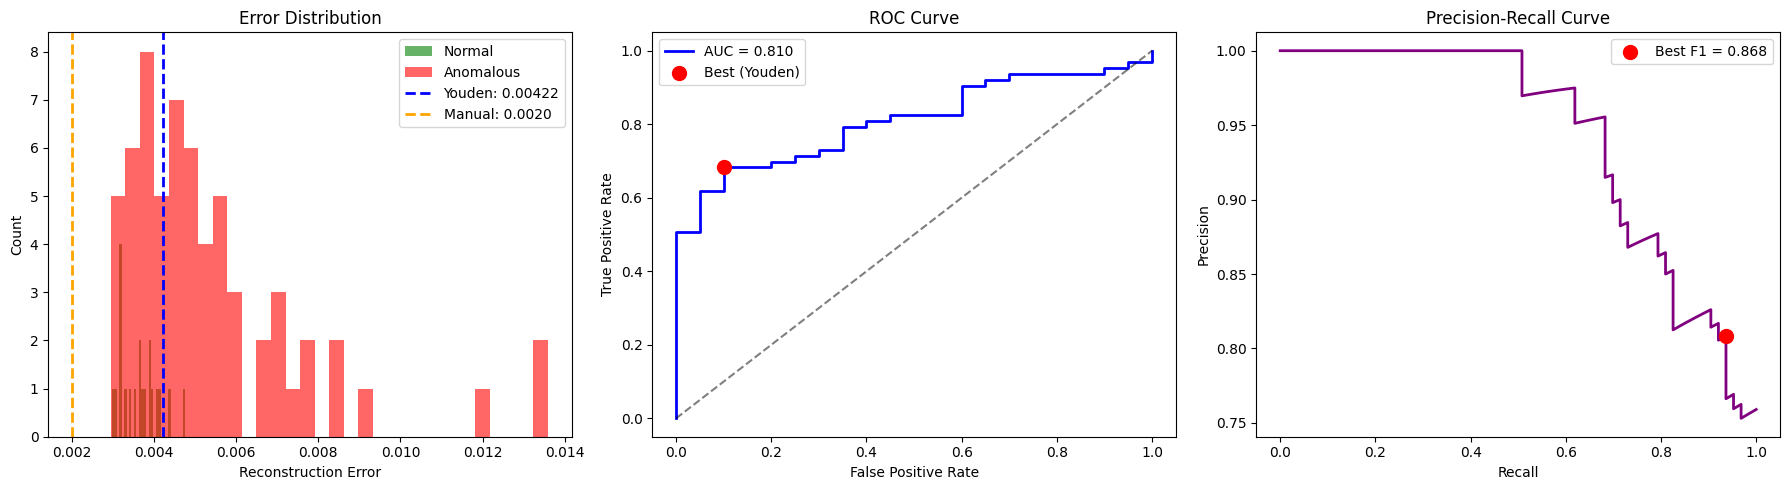

In [169]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


normal_errors = all_errors_np[all_labels_np == 0]
anomalous_errors = all_errors_np[all_labels_np == 1]

axes[0].hist(normal_errors, bins=30, alpha=0.6, label="Normal", color="green")
axes[0].hist(anomalous_errors, bins=30, alpha=0.6, label="Anomalous", color="red")
axes[0].axvline(threshold_youden, color="blue", linestyle="--", linewidth=2, label=f"Youden: {threshold_youden:.5f}")
axes[0].axvline(0.0020, color="orange", linestyle="--", linewidth=2, label=f"Manual: 0.0020")
axes[0].set_xlabel("Reconstruction Error")
axes[0].set_ylabel("Count")
axes[0].set_title("Error Distribution")
axes[0].legend()

# 2. ROC Curve
axes[1].plot(fpr, tpr, color="blue", linewidth=2, label=f"AUC = {roc_auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].scatter(fpr[best_roc_idx], tpr[best_roc_idx], color="red", s=100, zorder=5, label=f"Best (Youden)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# 3. Precision-Recall Curve
axes[2].plot(recall, precision, color="purple", linewidth=2)
axes[2].scatter(recall[best_pr_idx], precision[best_pr_idx], color="red", s=100, zorder=5, label=f"Best F1 = {f1_scores[best_pr_idx]:.3f}")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall Curve")
axes[2].legend()

plt.tight_layout()
plt.show()

In [170]:

best_threshold = threshold_youden 
print(f"Using optimal threshold: {best_threshold:.6f}")

optimal_preds = [1 if e > best_threshold else 0 for e in all_errors]

print(f"\nAccuracy: {accuracy_score(all_labels_np, optimal_preds):.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(all_labels_np, optimal_preds))
print(f"\nClassification Report:")
print(classification_report(all_labels_np, optimal_preds, target_names=["Normal", "Anomaly"]))

Using optimal threshold: 0.004224

Accuracy: 0.7229

Confusion Matrix:
[[18  2]
 [21 42]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.46      0.90      0.61        20
     Anomaly       0.95      0.67      0.79        63

    accuracy                           0.72        83
   macro avg       0.71      0.78      0.70        83
weighted avg       0.84      0.72      0.74        83



In [171]:
torch.save(model.state_dict(), "conv_autoencoder3.pth")